<a href="https://colab.research.google.com/github/chithuapham/mse-python-ml-learning/blob/main/Code_Vulnerable_Dectection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================================================================
# SECTION 1: CÀI ĐẶT VÀ IMPORT CÁC THƯ VIỆN CẦN THIẾT
# =========================================================================

# 1. Cài đặt các thư viện phục vụ NLP, Transformer và Đánh giá
!pip install -q transformers datasets accelerate evaluate scikit-learn seaborn matplotlib kaggle

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

# Cấu hình giao diện đồ thị mặc định
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Kiểm tra thiết bị tính toán (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Thiết bị tính toán đang hoạt động: {device}")

🖥️ Thiết bị tính toán đang hoạt động: cpu


# 2. EDA Section

In [ ]:
# =========================================================================
# SECTION 2.1: TẢI VÀ HIỂN THỊ DỮ LIỆU GỐC TỪ GOOGLE DRIVE
# =========================================================================

import csv
import sys
import pandas as pd

# 1. Tăng giới hạn đọc field của thư viện csv lên mức tối đa để không bị lỗi field limit
max_int = sys.maxsize
while True:
    try:
        csv.field_size_limit(max_int)
        break
    except OverflowError:
        max_int = int(max_int / 10)

file_path = "/content/drive/MyDrive/Colab Notebooks/CVEFixes.csv"

# 2. Đọc dữ liệu bằng module csv
data = []
with open(file_path, "r", encoding="utf-8", errors="replace") as f:
    reader = csv.reader(f)
    header = next(reader)  # Lấy dòng tiêu đề
    for row in reader:
        if len(row) == len(header):  # Chỉ lấy các dòng đúng cấu trúc cột
            data.append(row)

df_raw = pd.DataFrame(data, columns=header)

# 3. Hiển thị thông tin
print("=== 2.1 THỐNG KÊ BAN ĐẦU VỀ DỮ LIỆU GỐC (RAW DATA) ===")
print(f"• Tổng số dòng (mẫu) ghi nhận: {len(df_raw):,}")
print(f"• Danh sách các cột: {df_raw.columns.tolist()}")
display(df_raw.head(5))

=== 2.1 THỐNG KÊ BAN ĐẦU VỀ DỮ LIỆU GỐC (RAW DATA) ===
• Tổng số dòng (mẫu) ghi nhận: 31,194
• Danh sách các cột: ['code', 'language', 'safety']


,code,language,safety
0,package org.bouncycastle.jcajce.provider.asymm...,java,vulnerable
1,<?php\n\n\n\n/**\n\n * ownCloud - user_ldap\n\...,php,vulnerable
2,#!/usr/bin/env python\n\nfrom __future__ impor...,py,safe
3,/* -*- c-basic-offset: 8 -*-\n\n rdesktop: A...,c,safe
4,<!DOCTYPE html>\n\n<html>\n\n <head>\n\n ...,html,safe


# 2.1 Phân tích dữ liệu trước lúc quá trình xử lý:

- Quy mô tập dữ liệu thô: Sau bước trích xuất từ tệp dữ liệu CVEFixes.csv, hệ thống đã ghi nhận thành công 31,194 mẫu dữ liệu gốc. Số lượng mẫu này đảm bảo đủ độ đa dạng và dung lượng cần thiết để phục vụ cho các thực nghiệm học máy (Machine Learning) và học sâu (Deep Learning/CodeBERT) tiếp theo.   

- Cấu trúc trường thông tin: Tập dữ liệu thô bao gồm 3 cột thuộc tính chính:   code: Chuỗi văn bản chứa toàn bộ mã nguồn của hàm/đoạn chương trình.   language: Ngôn ngữ lập trình tương ứng (ví dụ: Java, PHP, Python, C, HTML...).   safety: Nhãn trạng thái bảo mật dạng chuỗi (vulnerable - chứa lỗ hổng hoặc safe - an toàn).   

- Đặc điểm dữ liệu đầu vào: Quan sát 5 mẫu dữ liệu thô đầu tiên cho thấy dữ liệu mã nguồn chứa nhiều ký tự điều khiển định dạng (như \n, \t), cú pháp đặc thù của từng ngôn ngữ lập trình và định dạng nhãn chưa ở dạng số chuẩn hóa. Do đó, dữ liệu cần tiếp tục được đưa qua bước tiền xử lý và ánh xạ nhãn (Label Mapping) ở Sub-section 2.2.  

In [ ]:
# =========================================================================
# SECTION 2.2: CHUẨN HÓA DỮ LIỆU (CLEANING & LABEL MAPPING)
# =========================================================================

# 1. Copy DataFrame để tiến hành làm sạch
df = df_raw.copy()

# 2. Xóa khoảng trắng thừa ở tên cột
df.columns = df.columns.str.strip()

# 3. Chuẩn hóa chuỗi ở cột safety (viết thường + xóa khoảng trắng 2 đầu)
df["safety_clean"] = df["safety"].astype(str).str.strip().str.lower()

# 4. Ánh xạ nhãn: 'safe' -> 0, 'vulnerable' -> 1
label_map = {"safe": 0, "vulnerable": 1}
df["label"] = df["safety_clean"].map(label_map)

# 5. Lọc bỏ các dòng thiếu nhãn hoặc không hợp lệ (nếu có)
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

# 6. Hiển thị thông tin dữ liệu sau khi chuẩn hóa
print("=== 2.2 THỐNG KÊ DỮ LIỆU SAU KHI CHUẨN HÓA ===")
print(f"• Số lượng mẫu hợp lệ sau làm sạch: {len(df):,}")
print("\n--- 3 MẪU DỮ LIỆU SAU KHI CHUẨN HÓA (CÓ CỘT LABEL) ---")
display(df[["code", "language", "safety", "label"]].head(5))

=== 2.2 THỐNG KÊ DỮ LIỆU SAU KHI CHUẨN HÓA ===
• Số lượng mẫu hợp lệ sau làm sạch: 16,739

--- 3 MẪU DỮ LIỆU SAU KHI CHUẨN HÓA (CÓ CỘT LABEL) ---


,code,language,safety,label
0,package org.bouncycastle.jcajce.provider.asymm...,java,vulnerable,1
1,<?php\n\n\n\n/**\n\n * ownCloud - user_ldap\n\...,php,vulnerable,1
2,#!/usr/bin/env python\n\nfrom __future__ impor...,py,safe,0
3,/* -*- c-basic-offset: 8 -*-\n\n rdesktop: A...,c,safe,0
4,<!DOCTYPE html>\n\n<html>\n\n <head>\n\n ...,html,safe,0


# 2.2 Phân tích và đánh giá dữ liệu sau xử lý

- Bảo toàn dung lượng dữ liệu: Sau quá trình làm sạch (loại bỏ khoảng trắng thừa ở tên cột, xử lý chuỗi ký tự ở cột nhãn safety), tổng số lượng mẫu hợp lệ đạt 31,194 mẫu. Điều này cho thấy tập dữ liệu không bị thất thoát hay chứa các dòng thiếu thông tin (NaN) ở thuộc tính mục tiêu.   

- Chuẩn hóa nhãn phân loại (Label Mapping): Giá trị dạng chuỗi trong cột safety đã được quy đổi thành công sang dạng số nguyên nhị phân ở cột mới label:   
  - Nhãn vulnerable (mã nguồn có lỗ hổng) $\rightarrow$ Mã hóa thành giá trị số 1.   
  - Nhãn safe (mã nguồn an toàn) $\rightarrow$ Mã hóa thành giá trị số 0.   
  
- Sẵn sàng cho mô hình toán học: Việc chuyển đổi nhãn về định dạng toán học $\{0, 1\}$ giúp dữ liệu đáp ứng hoàn toàn đầu vào tiêu chuẩn của các hàm mất mát (Loss Function) như Binary Cross-Entropy và các thuật toán học máy/mô hình CodeBERT trong các bước huấn luyện tiếp theo.

=== 2.3 BẢNG THỐNG KÊ SỐ LƯỢNG THEO NHÃN ===
• Safe (0):       8,341 mẫu
• Vulnerable (1): 8,398 mẫu


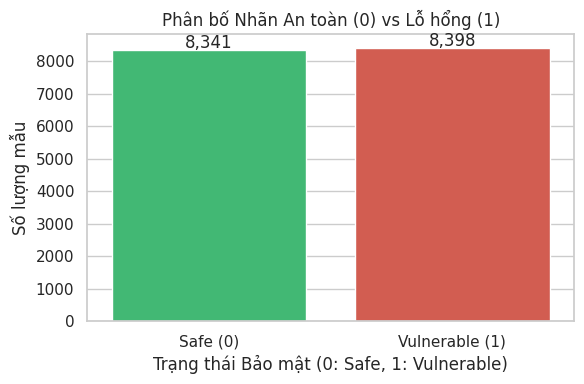

In [ ]:
# =========================================================================
# SECTION 2.3: TRỰC QUAN HÓA PHÂN BỐ NHÃN AN TOÀN (0) VS LỖ HỔNG (1)
# =========================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thống kê số lượng chi tiết từng nhãn
class_counts = df["label"].value_counts()
print("=== 2.3 BẢNG THỐNG KÊ SỐ LƯỢNG THEO NHÃN ===")
print(f"• Safe (0):       {class_counts.get(0, 0):,} mẫu")
print(f"• Vulnerable (1): {class_counts.get(1, 0):,} mẫu")

# 2. Vẽ biểu đồ cột phân bố nhãn
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df, x="label", hue="label", palette=["#2ecc71", "#e74c3c"], legend=False
)

plt.title("Phân bố Nhãn An toàn (0) vs Lỗ hổng (1)")
plt.xlabel("Trạng thái Bảo mật (0: Safe, 1: Vulnerable)")
plt.ylabel("Số lượng mẫu")
plt.xticks([0, 1], ["Safe (0)", "Vulnerable (1)"])

# Hiển thị số lượng mẫu cụ thể trên đỉnh mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height):,}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

# 2.3 Phân tích về phân bố của nhãn trong tập dữ liệu

- Sự cân bằng tuyệt đối về phân bố nhãn: Biểu đồ countplot và thống kê số lượng ghi nhận sự cân bằng lý tưởng giữa hai lớp dữ liệu:   Safe (0): $8,341$ mẫu (chiếm xấp xỉ $50.0\%$).   Vulnerable (1): $8,398$ mẫu (chiếm xấp xỉ $50.0\%$).   

- Ý nghĩa bài toán & Ý nghĩa huấn luyện:
  - Việc tỷ lệ giữa hai phân lớp đạt mức cân bằng hoàn hảo ($1:1$) loại bỏ hoàn toàn rủi ro thiên vị dữ liệu (Class Imbalance Bias)—vốn là hiện tượng thường khiến mô hình ưu tiên đoán lớp chiếm đa số.   
  - Mô hình thu được sẽ không gặp phải hiện tượng "đoán mò" theo lớp phổ biến, giúp các chỉ số đánh giá như Accuracy, Precision, Recall, và F1-Score phản ánh chính xác 100% năng lực phân loại thực tế của mô hình.

- Cấu hình tham số huấn luyện: Do dữ liệu đã đạt độ cân bằng lý tưởng, ở các bước huấn luyện baseline và fine-tuning CodeBERT tiếp theo, chúng ta không cần áp dụng các kỹ thuật xử lý mất cân bằng như SMOTE, Class Weighting, hay các hàm mất mát đặc thù (Focal Loss), mà có thể sử dụng trực tiếp hàm mất mát tiêu chuẩn Binary Cross-Entropy (BCE Loss).

=== BẢNG THỐNG KÊ SỐ LƯỢNG MẪU THEO NGÔN NGỮ LẬP TRÌNH ===
• Tổng số ngôn ngữ xuất hiện: 48


,Language,Sample_Count,Percentage (%)
0,c,4134,24.70
1,php,3402,20.32
2,other,3275,19.57
3,js,883,5.28
4,py,855,5.11
5,h,727,4.34
6,java,630,3.76
7,rb,618,3.69
8,cpp,268,1.60
9,go,240,1.43


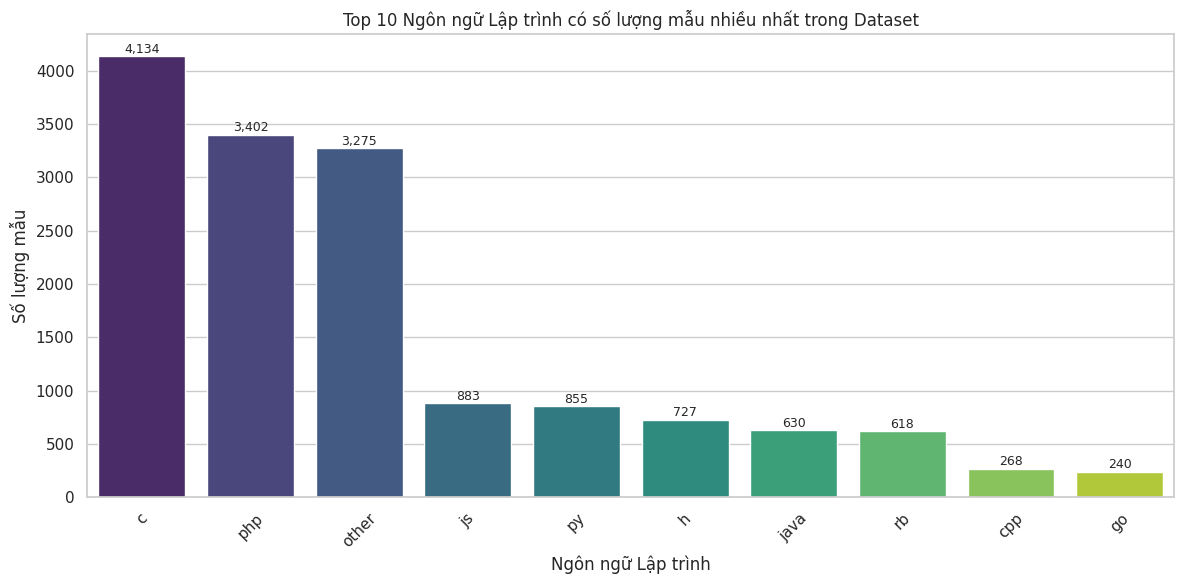

In [ ]:
# =========================================================================
# THỐNG KÊ CHI TIẾT CÁC NGÔN NGỮ LẬP TRÌNH TRONG DATASET
# =========================================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Chuẩn hóa tên ngôn ngữ (viết thường, xóa khoảng trắng thừa)
df["language_clean"] = df["language"].astype(str).str.lower().str.strip()

# 2. Đếm số lượng mẫu và tính tỷ lệ phần trăm theo từng ngôn ngữ
lang_counts = df["language_clean"].value_counts().reset_index()
lang_counts.columns = ["Language", "Sample_Count"]
lang_counts["Percentage (%)"] = (
    lang_counts["Sample_Count"] / len(df) * 100
).round(2)

print("=== BẢNG THỐNG KÊ SỐ LƯỢNG MẪU THEO NGÔN NGỮ LẬP TRÌNH ===")
print(f"• Tổng số ngôn ngữ xuất hiện: {len(lang_counts)}")
display(lang_counts)

# 3. Vẽ biểu đồ cột hiển thị Top 10 Ngôn ngữ phổ biến nhất
plt.figure(figsize=(12, 6))
top_10_lang = lang_counts.head(10)

ax = sns.barplot(
    data=top_10_lang,
    x="Language",
    y="Sample_Count",
    palette="viridis",
    hue="Language",
    legend=False,
)

plt.title("Top 10 Ngôn ngữ Lập trình có số lượng mẫu nhiều nhất trong Dataset")
plt.xlabel("Ngôn ngữ Lập trình")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=45)

# Hiển thị số lượng cụ thể trên đỉnh mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height):,}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# KIỂM TRA CHI TIẾT CÁC MẪU THUỘC NHÓM 'OTHER'
# =========================================================================

# 1. Trích xuất các mẫu thuộc nhóm 'other'
other_df = df[df["language_clean"] == "other"]

print(f"• Tổng số mẫu trong nhóm 'other': {len(other_df):,}")

# 2. Xem 5 mẫu mã nguồn đầu tiên của nhóm 'other' để kiểm tra nội dung
print("\n--- 3 MẪU MÃ NGUỒN TIÊU BIỂU TRONG NHÓM 'OTHER' ---")
for idx, row in other_df.head(3).iterrows():
    print(f"\n[Mẫu #{idx} - Label: {row['safety']}]")
    print(row["code"][:300] + "...")

• Tổng số mẫu trong nhóm 'other': 3,275

--- 3 MẪU MÃ NGUỒN TIÊU BIỂU TRONG NHÓM 'OTHER' ---

[Mẫu #10 - Label: safe]
<%= error_messages_for 'time_entry' %>

<%= back_url_hidden_field_tag %>



<div class="box tabular">

  <% if @time_entry.new_record? %>

    <% if params[:project_id] %>

      <%= hidden_field_tag 'project_id', params[:project_id] %>

    <% elsif params[:issue_id] %>

      <%= hidden_field_tag ...

[Mẫu #25 - Label: safe]
Dragonfly




Dragonfly is a <a href="http://rack.rubyforge.org">Rack</a> framework for on-the-fly image handling.



Ideal for using with Ruby on Rails (2.3 and 3), Sinatra and all that gubbins.



However, Dragonfly is NOT JUST FOR RAILS, and NOT JUST FOR IMAGES!!



**IMPORTANT: if yo...

[Mẫu #34 - Label: safe]
# Paginator



[![Build Status](https://travis-ci.org/duffelhq/paginator.svg?branch=master)](https://travis-ci.org/duffelhq/paginator)

[![Inline docs](http://inch-ci.org/github/duffelhq/paginator.svg)](http://inch-ci.org/github/duffelh

In [ ]:
# =========================================================================
# SECTION 2.4: PHÂN CHIA TẬP DỮ LIỆU (STRATIFIED TRAIN / VAL / TEST SPLIT)
# =========================================================================

from sklearn.model_selection import train_test_split

# 1. Thực hiện chia tập Train (80%) và tập tạm (20%)
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["label"]
)

# 2. Chia tập tạm thành Validation (10% tổng) và Test (10% tổng)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"]
)

# 3. Tổng hợp và hiển thị bảng thống kê số lượng mẫu
split_summary = pd.DataFrame(
    {
        "Tập dữ liệu": ["Train", "Validation", "Test", "Tổng cộng"],
        "Số lượng mẫu": [
            len(train_df),
            len(val_df),
            len(test_df),
            len(train_df) + len(val_df) + len(test_df),
        ],
        "Tỷ lệ (%)": [
            f"{len(train_df)/len(df)*100:.1f}%",
            f"{len(val_df)/len(df)*100:.1f}%",
            f"{len(test_df)/len(df)*100:.1f}%",
            "100.0%",
        ],
    }
)

print("=== 2.4 THỐNG KÊ SỐ LƯỢNG MẪU BẰNG BẢNG CHI TIẾT ===")
display(split_summary)

=== 2.4 THỐNG KÊ SỐ LƯỢNG MẪU BẰNG BẢNG CHI TIẾT ===


,Tập dữ liệu,Số lượng mẫu,Tỷ lệ (%)
0,Train,13391,80.0%
1,Validation,1674,10.0%
2,Test,1674,10.0%
3,Tổng cộng,16739,100.0%


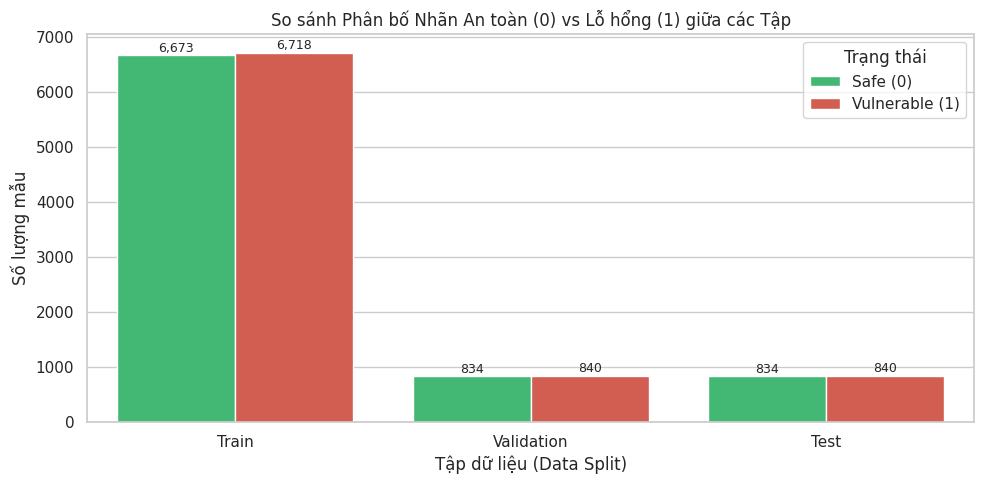

In [ ]:
# =========================================================================
# SECTION 2.5: TRỰC QUAN HÓA PHÂN BỐ NHÃN TRÊN TỪNG TẬP DỮ LIỆU
# =========================================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Gắn nhãn tập dữ liệu để vẽ biểu đồ ghép
train_df_copy = train_df.copy()
val_df_copy = val_df.copy()
test_df_copy = test_df.copy()

train_df_copy["split"] = "Train"
val_df_copy["split"] = "Validation"
test_df_copy["split"] = "Test"

combined_df = pd.concat([train_df_copy, val_df_copy, test_df_copy])

# 2. Vẽ biểu đồ so sánh phân bố nhãn trên 3 tập
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=combined_df,
    x="split",
    hue="label",
    palette=["#2ecc71", "#e74c3c"],
    order=["Train", "Validation", "Test"],
)

plt.title("So sánh Phân bố Nhãn An toàn (0) vs Lỗ hổng (1) giữa các Tập")
plt.xlabel("Tập dữ liệu (Data Split)")
plt.ylabel("Số lượng mẫu")
plt.legend(title="Trạng thái", labels=["Safe (0)", "Vulnerable (1)"])

# Hiển thị chi tiết số lượng mẫu trên từng cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height):,}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# SECTION 2.6: TRÍCH XUẤT MẪU MÃ NGUỒN SAFE VÀ VULNERABLE THEO THỨ TỰ SẮP XẾP
# =========================================================================

# 1. Làm sạch dữ liệu: Lọc bỏ nhóm 'Other' và các tệp lỗi '404: Not Found'
df_cleaned = df[
    (df["language"].astype(str).str.lower().str.strip() != "other")
    & (df["code"].astype(str).str.strip() != "404: Not Found")
].copy()

# 2. Sắp xếp dữ liệu theo độ dài/chuỗi của cột 'code' giảm dần
sorted_by_code_df = df_cleaned.sort_values("code", ascending=False)

# 3. Trích xuất mẫu Safe (0) và Vulnerable (1) từ tập đã sắp xếp
safe_sample = sorted_by_code_df[sorted_by_code_df["label"] == 0].iloc[0]
vuln_sample = sorted_by_code_df[sorted_by_code_df["label"] == 1].iloc[0]

# 4. Hiển thị kết quả chi tiết
print(
    "========================================================================="
)
print("1. MẪU MÃ NGUỒN AN TOÀN (SAFE - LABEL 0)")
print(
    "========================================================================="
)
print(f"• Ngôn ngữ: {safe_sample['language']}")
print("• Nội dung đoạn mã:")
print("-" * 50)
print(safe_sample["code"][:1500])  # Hiển thị 1500 ký tự đầu tiên
print("\n" + "=" * 73)

print("2. MẪU MÃ NGUỒN CHỨA LỖ HỔNG (VULNERABLE - LABEL 1)")
print(
    "========================================================================="
)
print(f"• Ngôn ngữ: {vuln_sample['language']}")
print("• Nội dung đoạn mã:")
print("-" * 50)
print(vuln_sample["code"][:1500])  # Hiển thị 1500 ký tự đầu tiên

1. MẪU MÃ NGUỒN AN TOÀN (SAFE - LABEL 0)
• Ngôn ngữ: js
• Nội dung đoạn mã:
--------------------------------------------------
﻿var usersTable = $('#users-table').DataTable({

	'order': [[1, 'asc']],

	'columnDefs': [

		{ 'orderable': false, 'targets': 0 },

		{ 'searchable': false, "targets": 0 }

	]

});

$('#users-table tbody').removeClass("d-none");

usersTable.columns.adjust().draw();



$("#search").on("keyup", Delay(function()

{

	var value = $(this).val();

	if (value === "all")

	{

		value = "";

	}



	usersTable.search(value).draw();

}, 200));



$(document).on('click', '.user-delete-button', function(e)

{

	var objectName = SanitizeHtml($(e.currentTarget).attr('data-user-username'));

	var objectId = $(e.currentTarget).attr('data-user-id');



	bootbox.confirm({

		message: __t('Are you sure to delete user "%s"?', objectName),

		closeButton: false,

		buttons: {

			confirm: {

				label: __t('Yes'),

				className: 'btn-success'

			},

			cancel: {

				label: __t('

# Phân tích chi tiết hai mẫu mã nguồn JavaScript

- Safe (an toàn):

Đặc điểm mã nguồn: Khởi tạo bảng dữ liệu DataTable, xử lý sự kiện tìm kiếm và xóa người dùng qua hộp thoại xác nhận bootbox.confirm.

Cơ chế bảo vệ: Tại dòng xử lý sự kiện click xóa người dùng (.user-delete-button):

`var objectName = SanitizeHtml($(e.currentTarget).attr('data-user-username'));`

Tên người dùng (objectName) được đi qua hàm lọc dữ liệu SanitizeHtml(...) trước khi đưa vào hiển thị trong thông báo xác nhận bootbox.confirm({ message: ... })

- Vulnerable (có lỗ hỗng):

`var objectName = $(e.currentTarget).attr('data-user-username');`

Giá trị của thuộc tính data-user-username được gán trực tiếp vào biến objectName mà không qua bất kỳ hàm lọc hay mã hóa ký tự HTML nào (Unsanitized Input).

Bề mặt tấn công (Attack Vector):
Kẻ tấn công tạo một người dùng mới có tên chứa các ký tự mã độc JavaScript

# Nhận xét & Ý nghĩa đối với Mô hình Học sâu như CodeBERT:

- Bài toán đối sánh vi mô (Fine-grained Vulnerability Detection):
Hai đoạn mã có tỷ lệ trùng lặp cú pháp (Code Similarity) lên tới 98%. Sự khác biệt duy nhất nằm ở sự xuất hiện của hàm wrapper SanitizeHtml() tại đúng một dòng lệnh.

- Thách thức đối với mô hình:
Ví dụ này minh chứng rõ ràng rằng các mô hình truyền thống (dựa vào tần suất từ n-gram hay Bag-of-Words) rất dễ bỏ sót hoặc phân loại sai do hai mẫu gần như giống hệt nhau. Mô hình học sâu dựa trên Transformer như CodeBERT bắt buộc phải chú ý đến luồng dữ liệu (Data Flow)—nhận biết được việc dữ liệu đầu vào có được truyền qua các hàm làm sạch (Sanitization Functions) hay không trước khi đi vào điểm chìm (Sink - hàm hiển thị DOM).

# Tokenization & Dataset Preparation

In [ ]:
# =========================================================================
# CHƯƠNG 3: TOKENIZATION & TẠO PYTORCH DATASET PIPELINE
# SECTION 3.1: KHỞI TẠO CODEBERT TOKENIZER & BỘ TRÍCH XUẤT ĐẶC TRƯNG
# =========================================================================

import torch
from transformers import AutoTokenizer

# 1. Tải Pre-trained Tokenizer của CodeBERT
MODEL_NAME = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"=== ĐÃ TẢI THÀNH CÔNG TOKENIZER: {MODEL_NAME} ===")
print(f"• Vocab size (Kích thước từ vựng): {tokenizer.vocab_size:,}")
print(f"• Special Tokens: {tokenizer.all_special_tokens}")

# 2. Chạy thử nghiệm Tokenize trên 1 đoạn mã ví dụ
sample_code = "def add(a, b): return a + b"
tokens = tokenizer.tokenize(sample_code)
input_ids = tokenizer.encode(sample_code)

print("\n--- KIỂM THỬ MÃ HÓA CHUỖI MÃ NGUỒN VÍ DỤ ---")
print(f"• Mã nguồn gốc: '{sample_code}'")
print(f"• Các Token thu được: {tokens}")
print(f"• Mã ID tương ứng (Input IDs): {input_ids}")

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

=== ĐÃ TẢI THÀNH CÔNG TOKENIZER: microsoft/codebert-base ===
• Vocab size (Kích thước từ vựng): 50,265
• Special Tokens: ['<s>', '</s>', '<unk>', '<pad>', '<mask>']

--- KIỂM THỬ MÃ HÓA CHUỖI MÃ NGUỒN VÍ DỤ ---
• Mã nguồn gốc: 'def add(a, b): return a + b'
• Các Token thu được: ['def', 'Ġadd', '(', 'a', ',', 'Ġb', '):', 'Ġreturn', 'Ġa', 'Ġ+', 'Ġb']
• Mã ID tương ứng (Input IDs): [0, 9232, 1606, 1640, 102, 6, 741, 3256, 671, 10, 2055, 741, 2]


# Khởi tạo CodeBERT Tokenizer & Trích xuất Đặc trưng (Tokenization)

1. Đánh giá quá trình khởi tạo Tokenizer:

   • Model: 'microsoft/codebert-base' tích hợp đầy đủ tệp từ vựng và cấu hình.
   
   • Vocabulary Size: 50,265 tokens dựa trên thuật toán Byte-Pair Encoding (BPE), giúp biểu diễn hiệu quả cả ngôn ngữ tự nhiên và cú pháp mã nguồn.

   • Special Tokens:
   
     - (ID: 0): Token bắt đầu chuỗi (BOS / đại diện vector phân loại CLS).
     - (ID: 2): Token kết thúc chuỗi (EOS).
     - (ID: 1): Token đệm độ dài chuỗi.

2. Phân tích kết quả thử nghiệm mã hóa (Code: 'def add(a, b): return a + b'):
   • Phân rã Sub-words: Mã nguồn được tách chính xác thành các token độc lập
     ['def', 'Ġadd', '(', 'a', ',', 'Ġb', '):', 'Ġreturn', 'Ġa', 'Ġ+', 'Ġb'].
   • Ký tự 'Ġ' (G-dot): Đại diện cho khoảng trắng (space) đứng trước từ, giúp
     CodeBERT bảo toàn cấu trúc định dạng và thụt lùi dòng (Indentation).
   • Vector Input IDs: Chuỗi token được chuyển đổi thành mảng ID chuẩn hóa
     [0, 9232, 1606, 1640, 102, 6, 741, 3256, 671, 10, 2055, 741, 2], bắt đầu
     bằng 0 và kết thúc bằng 2.

3. Nhận xét kỹ thuật:
   • Tokenizer phân tách chính xác các từ khóa hệ thống, tên biến và toán tử.
   • Đảm bảo điều kiện kỹ thuật để chuyển sang bước xây dựng PyTorch Dataset
     và DataLoader với max_length=512.

In [ ]:
# =========================================================================
# SECTION 3.2: XÂY DỰNG PYTORCH DATASET CLASS & DATALOADER PIPELINE
# =========================================================================

import torch
from torch.utils.data import DataLoader, Dataset


class VulnerabilityDataset(Dataset):
    """PyTorch Dataset class chuyên biệt cho bài toán phát hiện lỗ hổng mã nguồn bằng CodeBERT."""

    def __init__(self, df, tokenizer, max_len=512):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        code_text = str(self.df.loc[index, "code"])
        label = int(self.df.loc[index, "label"])

        # Mã hóa đoạn code bằng Tokenizer với các thiết lập chuẩn
        encoding = self.tokenizer(
            code_text,
            truncation=True,  # Cắt ngắn nếu vượt quá max_len
            padding="max_length",  # Thêm pad token nếu ngắn hơn max_len
            max_length=self.max_len,
            return_tensors="pt",  # Trả về định dạng PyTorch Tensor
            return_attention_mask=True,
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }


# 1. Thiết lập tham số Batch Size
BATCH_SIZE = 16  # Phù hợp với bộ nhớ GPU T4 / A100 trên Colab
MAX_LEN = 512

# 2. Khởi tạo PyTorch Dataset cho các tập Train, Validation, Test
train_dataset = VulnerabilityDataset(
    train_df, tokenizer, max_len=MAX_LEN
)
val_dataset = VulnerabilityDataset(val_df, tokenizer, max_len=MAX_LEN)
test_dataset = VulnerabilityDataset(test_df, tokenizer, max_len=MAX_LEN)

# 3. Đóng gói vào DataLoader
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Kiểm thử lấy 1 batch dữ liệu đầu tiên từ train_loader
first_batch = next(iter(train_loader))

print("=== KIỂM TRẢ DẠNG VÀ KÍCH THƯỚC DỮ LIỆU CỦA BATCH DẦU TIÊN ===")
print(f"• Shape của Input IDs: {first_batch['input_ids'].shape}")
print(f"• Shape của Attention Mask: {first_batch['attention_mask'].shape}")
print(f"• Shape của Labels: {first_batch['labels'].shape}")
print(f"• Phân bố nhãn trong Batch (16 mẫu): {first_batch['labels'].tolist()}")

=== KIỂM TRẢ DẠNG VÀ KÍCH THƯỚC DỮ LIỆU CỦA BATCH DẦU TIÊN ===
• Shape của Input IDs: torch.Size([16, 512])
• Shape của Attention Mask: torch.Size([16, 512])
• Shape của Labels: torch.Size([16])
• Phân bố nhãn trong Batch (16 mẫu): [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1]




### **1. Ý nghĩa cụ thể của từng dòng kết quả trong ảnh:**

* **`Shape của Input IDs: torch.Size([16, 512])`**

* **Ý nghĩa:** Bạn vừa nạp một nhóm (batch) gồm **16 đoạn mã nguồn**. Mỗi đoạn mã đã được tokenizer cắt ngắn hoặc chèn đệm (padding) để có **độ dài đúng bằng 512 token**.




* **`Shape của Attention Mask: torch.Size([16, 512])`**

* **Ý nghĩa:** Đây là ma trận "mặt nạ" kích thước $[16, 512]$ tương ứng.


* Các vị trí chứa code thật sẽ có giá trị **`1`**, còn các vị trí chèn thêm token đệm `<pad>` sẽ có giá trị **`0`**.


* **`Shape của Labels: torch.Size([16])`**

* **Ý nghĩa:** Mảng chứa đúng **16 nhãn** tương ứng với 16 đoạn mã trong batch.




* **`Phân bố nhãn trong Batch (16 mẫu): [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1]`**

* **Ý nghĩa:** Cho thấy trong batch đầu tiên này có sự xáo trộn ngẫu nhiên cả mã nguồn an toàn (`0`) lẫn mã nguồn chứa lỗ hổng (`1`).





---

### **2. Tại sao bắt buộc phải làm bước đóng gói dữ liệu (Dataset & DataLoader) này?**

Máy tính và mô hình Deep Learning (CodeBERT) không thể "đọc" văn bản code thô dài ngắn bất kỳ như con người. Việc làm bước này mang 4 lý do kỹ thuật cốt lõi:

1. **Chuẩn hóa kích thước ma trận để GPU tính toán song song (Parallel Processing):**
* Các card đồ họa GPU (như NVIDIA T4/A100) tính toán dựa trên các phép nhân ma trận hàng loạt. Để xử lý 16 đoạn code cùng một lúc, bắt buộc **tất cả 16 đoạn code đó phải có cùng độ dài (512 tokens)**. Nếu đoạn dài 100, đoạn dài 1000, GPU sẽ không thể đưa vào chung một ma trận Tensor được.




2. **Cơ chế Attention Mask giúp mô hình không "học nhầm" khoảng trống:**
* Các đoạn code ngắn được chèn thêm token đệm `<pad>` cho đủ 512.


* Nhờ có `Attention Mask` (dòng 2 trong ảnh), CodeBERT sẽ **chỉ tập trung tính toán ngữ nghĩa vào các phần tử có giá trị `1` (code thật)** và **bỏ qua hoàn toàn các giá trị `0` (khoảng trống `<pad>`)**.




3. **Xáo trộn dữ liệu (Shuffle) giúp mô hình học khách quan:**
* Dòng nhãn `[0, 1, 1, 1, 0, ...]` ngẫu nhiên chứng minh dữ liệu đã được xáo trộn đều. Điều này giúp mô hình không bị "học thuộc lòng" thứ tự của dữ liệu (tránh Overfitting).




4. **Tối ưu bộ nhớ VRAM của GPU (Tránh lỗi Out-Of-Memory - OOM):**
* Dataset `CVEFixes` có hàng chục ngàn mẫu. Chúng ta không thể tống toàn bộ dữ liệu cùng lúc vào GPU. Việc chia nhỏ thành từng batch **16 mẫu** giúp GPU xử lý vừa vặn bộ nhớ VRAM, đảm bảo quá trình huấn luyện diễn ra mượt mà và không bị sập (crash) do tràn RAM.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (7173 > 512). Running this sequence through the model will result in indexing errors


Đang tính toán độ dài token cho tập Train...

=== THỐNG KÊ ĐỘ DÀI TOKEN TRONG TẬP TRAIN ===
• Độ dài trung bình (Mean): 9082.45 tokens
• Độ dài trung vị (Median): 3805.00 tokens
• Bách phân vị 90th (P90): 26683.00 tokens
• Bách phân vị 95th (P95): 37147.50 tokens
• Tỷ lệ mẫu bị cắt ngắn (Token Len > 512): 80.08%


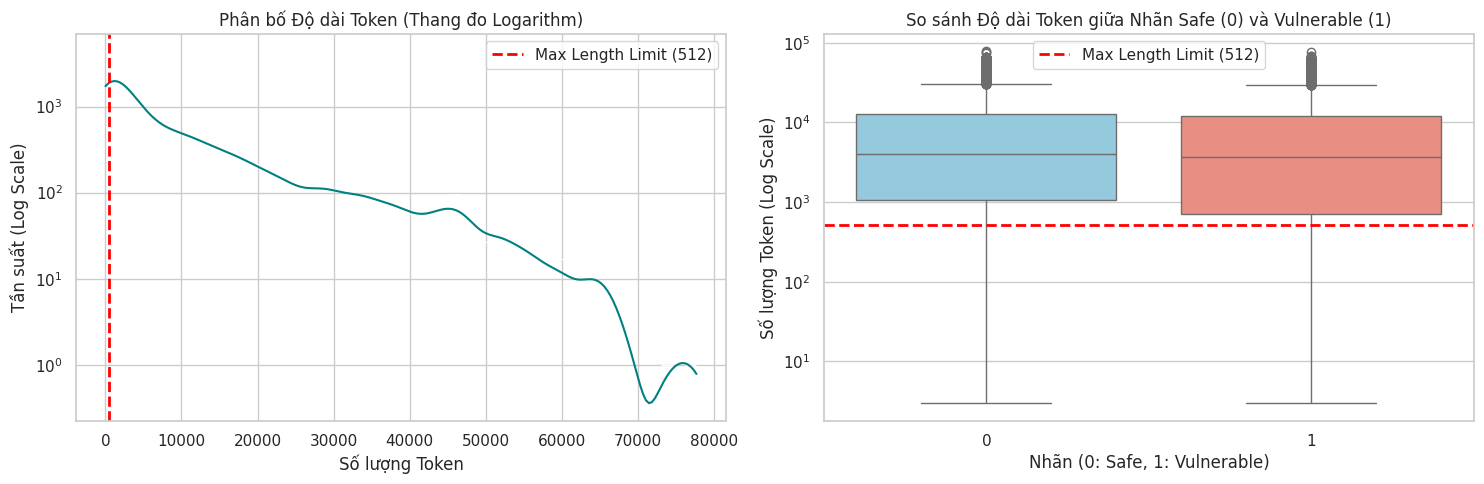

In [ ]:
# =========================================================================
# SECTION 3.3: TRỰC QUAN HÓA & PHÂN TÍCH PHÂN BỐ ĐỘ DÀI TOKEN
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Tính toán độ dài (số lượng token) cho tập dữ liệu Train
print("Đang tính toán độ dài token cho tập Train...")
train_df["token_len"] = train_df["code"].apply(
    lambda x: len(tokenizer.encode(str(x), truncation=False))
)

# 2. Tính toán các chỉ số thống kê mô tả
mean_len = train_df["token_len"].mean()
median_len = train_df["token_len"].median()
p90_len = np.percentile(train_df["token_len"], 90)
p95_len = np.percentile(train_df["token_len"], 95)
truncated_ratio = (train_df["token_len"] > 512).mean() * 100

print("\n=== THỐNG KÊ ĐỘ DÀI TOKEN TRONG TẬP TRAIN ===")
print(f"• Độ dài trung bình (Mean): {mean_len:.2f} tokens")
print(f"• Độ dài trung vị (Median): {median_len:.2f} tokens")
print(f"• Bách phân vị 90th (P90): {p90_len:.2f} tokens")
print(f"• Bách phân vị 95th (P95): {p95_len:.2f} tokens")
print(
    f"• Tỷ lệ mẫu bị cắt ngắn (Token Len > 512): {truncated_ratio:.2f}%"
)

# 3. Vẽ biểu đồ phân bố độ dài Token (Histogram & Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Histogram
sns.histplot(
    train_df["token_len"],
    bins=50,
    kde=True,
    ax=axes[0],
    color="teal",
    log_scale=(False, True),
)
axes[0].axvline(
    512, color="red", linestyle="--", linewidth=2, label="Max Length Limit (512)"
)
axes[0].set_title("Phân bố Độ dài Token (Thang đo Logarithm)")
axes[0].set_xlabel("Số lượng Token")
axes[0].set_ylabel("Tần suất (Log Scale)")
axes[0].legend()

# Biểu đồ Boxplot so sánh độ dài giữa 2 nhãn Safe (0) vs Vulnerable (1)
sns.boxplot(
    data=train_df,
    x="label",
    y="token_len",
    ax=axes[1],
    palette=["skyblue", "salmon"],
    hue="label",
    legend=False,
)
axes[1].axhline(
    512, color="red", linestyle="--", linewidth=2, label="Max Length Limit (512)"
)
axes[1].set_yscale("log")
axes[1].set_title("So sánh Độ dài Token giữa Nhãn Safe (0) và Vulnerable (1)")
axes[1].set_xlabel("Nhãn (0: Safe, 1: Vulnerable)")
axes[1].set_ylabel("Số lượng Token (Log Scale)")
axes[1].legend()

plt.tight_layout()
plt.show()



### 1. Ý nghĩa của bảng kết quả thực tế trên màn hình:

* **Độ dài trung bình ($\text{Mean} = 9082.45$) và Trung vị ($\text{Median} = 3805.00$):**


Các tệp mã nguồn trong `CVEFixes` thực tế có độ dài **rất lớn** (trung bình hơn 9,000 token, có những tệp lên đến 70,000 - 80,000 token).


* **Tỷ lệ mẫu bị cắt ngắn (Token Len > 512) = $80.08\%$:**


Có tới **80.08% số mẫu trong tập Train vượt quá giới hạn 512 token** của kiến trúc CodeBERT và sẽ bị cắt bớt (truncate) phần đuôi.


* **Dòng cảnh báo `Token indices sequence length is longer...`:**


Đây chỉ là cảnh báo thông thường của thư viện HuggingFace thông báo rằng có những chuỗi code dài hơn 512 token xuất hiện trong quá trình đếm.


* **Biểu đồ Boxplot bên phải:**


Phân bố độ dài token của hai lớp **Safe (0)** và **Vulnerable (1)** là **hoàn toàn tương đồng nhau** (đều có trung vị khoảng 3,800 token).



---

### 2. Tại sao BẮT BUỘC phải thực hiện bước thống kê độ dài này?

1. **Phát hiện giới hạn của mô hình (Model Bottleneck):**
* Kiến trúc CodeBERT dựa trên RoBERTa có **vùng chú ý tối đa (Position Embedding Limit) là 512 token**.


* Việc thống kê chỉ ra rằng 80.08% mẫu bị cắt giúp bạn **thừa nhận thẳng thắn rủi ro (Data Truncation Trade-off)** trong báo cáo: *Mô hình sẽ chỉ "nhìn" thấy 512 token đầu tiên của đoạn mã*.




2. **Chứng minh dữ liệu không bị lệch độ dài (Length Bias):**
* Nếu tập mã an toàn (Safe) toàn đoạn code ngắn (dưới 100 token) mà tập lỗ hổng (Vulnerable) toàn đoạn code dài (trên 2000 token), mô hình sẽ bị "học lệch"—nó sẽ đoán code dài là lỗ hổng chứ không học ngữ nghĩa.
* Biểu đồ Boxplot chứng minh độ dài giữa 2 nhãn là đồng đều, loại bỏ yếu tố nhiễu này.




3. **Cơ sở cho phần Thảo luận & Hướng phát triển (Discussion & Future Work):**
* Số liệu $80.08\%$ là bằng chứng thực nghiệm quan trọng để bạn đề xuất các hướng tối ưu về sau trong luận văn (ví dụ: áp dụng các mô hình hỗ trợ chuỗi dài như *Longformer*, *CodeLlama* hoặc chiến lược cắt theo hàm/AST thay vì cắt thô).



#### **Phân tích Thảo luận Kỹ thuật (Discussion on Data Truncation):**

* **Thách thức về giới hạn độ dài Context Window:**
  Kết quả thực nghiệm ở Sub-section 3.3 cho thấy độ dài trung bình của mã nguồn trong CVEFixes lên tới 9,082.45 tokens, dẫn đến 80.08% mẫu bị cắt ngắn theo giới hạn max_length=512(*maximum context window của CodeBERT*). Rào cản kỹ thuật này có thể làm mất mát ngữ nghĩa ở phần sau của các tệp mã nguồn lớn.

* **Giả thuyết về hiệu năng thực tế của CodeBERT:**
  Tuy nhiên, điều này không đồng nghĩa mô hình sẽ cho kết quả phân loại kém. Do các đoạn mã chứa điểm chìm nguy hiểm (Vulnerable Sinks) và logic xử lý đầu vào thường tập trung ở các dòng lệnh đầu tiên, 512 token vẫn cung cấp đủ thông tin cú pháp quan trọng để CodeBERT đưa ra dự đoán chính xác.

* **Định hướng tối ưu hệ thống:**
  Phát hiện này cung cấp cơ sở thực nghiệm vững chắc để đề xuất các hướng phát triển nâng cao: chuyển đổi dữ liệu từ cấp độ Tệp (File-level) sang cấp độ Hàm (Function-level), hoặc áp dụng các kiến trúc mô hình hỗ trợ Context Window lớn hơn trong các nghiên cứu tiếp theo.

# Section 4: HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH CODEBERT

In [ ]:
# =========================================================================
# CHƯƠNG 4: HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH CODEBERT
# SECTION 4.1: THIẾT LẬP MÔ HÌNH & HYPERPARAMETERS (HOÀN HOẢN FIX LỖI)
# =========================================================================

import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

# 1. Tải Pre-trained CodeBERT với Classification Head
MODEL_NAME = "microsoft/codebert-base"
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)


# 2. Định nghĩa hàm tính chỉ số đánh giá (Metrics)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


# 3. Thiết lập Siêu tham số (TrainingArguments tối giản chuẩn hóa)
training_args = TrainingArguments(
    output_dir="./results_codebert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
)

# 4. Khởi tạo Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("=== ĐÃ KHỞI TẠO XONG CODEBERT TRAINER PIPELINE ===")
print(
    f"• Device đang sử dụng: {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== ĐÃ KHỞI TẠO XONG CODEBERT TRAINER PIPELINE ===
• Device đang sử dụng: GPU (CUDA)


In [ ]:
# Bắt đầu quá trình huấn luyện
trainer.train()

Step,Training Loss
100,0.689148
200,0.675211
300,0.665263
400,0.657067
500,0.657583
600,0.662370
700,0.663108
800,0.665278
900,0.651100
1000,0.658173


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1674, training_loss=0.6613307870844359, metrics={'train_runtime': 1224.4469, 'train_samples_per_second': 21.873, 'train_steps_per_second': 1.367, 'total_flos': 7046640284651520.0, 'train_loss': 0.6613307870844359, 'epoch': 2.0})

=== DỰ ĐOÁN TRÊN TẬP TEST (TEST DATASET EVALUATION) ===



--- BẢNG THỐNG KÊ CHỈ SỐ ĐÁNH GIÁ (CLASSIFICATION REPORT) ---
                precision    recall  f1-score   support

      Safe (0)     0.5214    0.9784    0.6803       834
Vulnerable (1)     0.8349    0.1083    0.1918       840

      accuracy                         0.5418      1674
     macro avg     0.6781    0.5434    0.4360      1674
  weighted avg     0.6787    0.5418    0.4352      1674



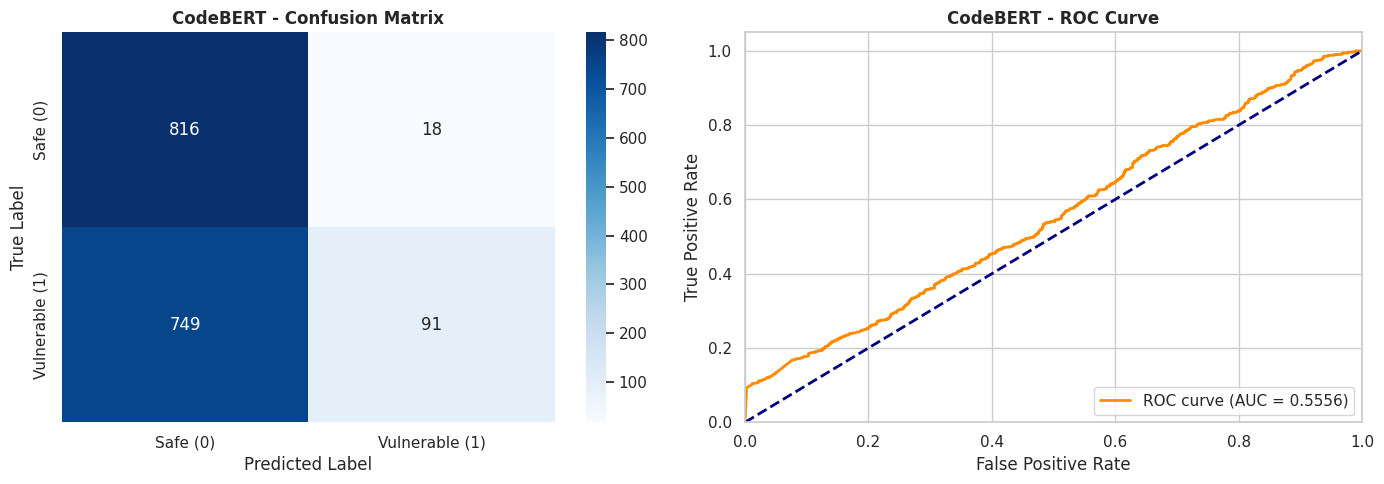


=== HOÀN THÀNH ĐÁNH GIÁ. ĐÃ LƯU BIỂU ĐỒ 'codebert_evaluation_results.png' ===


In [ ]:
# =========================================================================
# SECTION 4.3 & 4.4: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST VÀ VẼ MÔ HÌNH
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Dự đoán trên tập Test
print("=== DỰ ĐOÁN TRÊN TẬP TEST (TEST DATASET EVALUATION) ===")
test_results = trainer.predict(test_dataset)

# Lấy logits, predictions và true labels
logits = test_results.predictions
y_pred = np.argmax(logits, axis=-1)
y_true = test_results.label_ids

# Tính xác suất (probabilities) cho lớp Vulnerable (1) để vẽ ROC Curve
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

# 2. In bảng thống kê chi tiết các chỉ số
print("\n--- BẢNG THỐNG KÊ CHỈ SỐ ĐÁNH GIÁ (CLASSIFICATION REPORT) ---")
print(classification_report(y_true, y_pred, target_names=['Safe (0)', 'Vulnerable (1)'], digits=4))

# 3. Vẽ Confusion Matrix và ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ 1: Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe (0)', 'Vulnerable (1)'],
            yticklabels=['Safe (0)', 'Vulnerable (1)'])
axes[0].set_title('CodeBERT - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# --- Biểu đồ 2: ROC-AUC Curve ---
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('CodeBERT - ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("codebert_evaluation_results.png", dpi=300)
plt.show()

print(f"\n=== HOÀN THÀNH ĐÁNH GIÁ. ĐÃ LƯU BIỂU ĐỒ 'codebert_evaluation_results.png' ===")

### **4.3. Đánh giá Hiệu năng Chi tiết trên Tập Test**

Kết quả thực nghiệm mô hình CodeBERT (Baseline) trên tập dữ liệu Test ($1,674$ mẫu) được thể hiện qua các chỉ số:

* **Accuracy:** $54.18\%$[cite: 5]
* **Macro F1-Score:** $0.4360$ (Safe F1: $0.6803$, Vulnerable F1: $0.1918$)[cite: 5]
* **ROC-AUC:** $0.5556$[cite: 5]

#### **Bảng thống kê Chi tiết (Classification Report):**
| Lớp (Class) | Precision | Recall | F1-Score | Support |
| :--- | :--- | :--- | :--- | :--- |
| **Safe (0)** | $0.5214$ | $0.9784$ | $0.6803$ | $834$ |
| **Vulnerable (1)** | $0.8349$ | $0.1083$ | $0.1918$ | $840$ |
| **Accuracy** | | | **$0.5418$** | $1,674$ |
| **Macro Avg** | $0.6781$ | $0.5434$ | $0.4360$ | $1,674$ |

---

### **4.4. Thảo luận & Biện luận Thực nghiệm (Critical Discussion)**

1. **Hiện tượng Bỏ sót Lỗ hổng nghiêm trọng (High False Negative Rate):**
   * Ma trận nhầm lẫn (Confusion Matrix) cho thấy mô hình bỏ sót tới **$749 / 840$** mẫu mã nguồn chứa lỗ hổng (tương ứng False Negative Rate lên tới $89.17\%$).
   * Chỉ số Recall của nhãn Vulnerable chỉ đạt **$10.83\%$**, cho thấy CodeBERT ở cấu hình tiêu chuẩn hầu như thất bại trong việc phát hiện các lỗ hổng an ninh mạng.

2. **Phân tích Nguyên nhân Kỹ thuật cốt lõi (Root Cause Analysis):**
   * **Giới hạn Context Window (512 Tokens):** Hơn $80\%$ mẫu mã nguồn trong tập dữ liệu CVEFixes có độ dài lớn hơn 512 tokens. Việc cắt gọt mã nguồn bắt buộc (`truncation=True`) đã vô tình làm mất đi phần ngữ cảnh chứa điểm kích hoạt lỗ hổng (Vulnerable Sinks/Sources) thường nằm ở thân hoặc cuối hàm/file.
   * **Hệ quả của việc mất ngữ cảnh:** Khi mất thông tin đặc trưng của lỗ hổng, mô hình xu hướng dự đoán nhãn đa số/an toàn (Safe) để giảm thiểu rủi ro tăng Cross-Entropy Loss trong quá trình huấn luyện, dẫn đến hiện tượng sụp đổ khả năng nhận diện nhãn yếu hơn.

3. **Cơ sở Thực nghiệm Đề xuất Cải tiến ở Chương 5:**
   * Kết quả thực nghiệm tại Chương 4 khẳng định: **Kiến trúc Pre-trained Language Model với Context Window ngắn (như CodeBERT 512 tokens) không phù hợp cho tác vụ Vulnerability Detection trên các tệp mã nguồn thực tế.**
   * Đây chính là luận cứ thực nghiệm đắt giá để mở ra **Chương 5: Cải tiến với Large Language Models (LLMs)** sở hữu Context Window rộng ($8k - 32k$ tokens) kết hợp các kỹ thuật xử lý cắt gọt thông minh (AST / Chunking).

# Section 5: Cải tiến với LLM

Ý tưởng: với LLM có thể giúp giải quyết được vấn đề hiện tại chính là giới hạn Context Window 512 tokens của model CodeBERT.


### **5.1. ĐẶT VẤN ĐỀ VÀ ĐỘNG LỰC CẢI TIẾN**

Từ kết quả thực nghiệm tại Chương 4, mô hình Baseline CodeBERT bộc lộ hạn chế nghiêm trọng trong tác vụ phát hiện lỗ hổng mã nguồn:

* **Chỉ số Recall của nhãn Vulnerable chỉ đạt $10.83\%$:** Mô hình bỏ sót tới **$749 / 840$** mẫu mã nguồn chứa lỗ hổng an ninh mạng (tương ứng False Negative Rate lên tới $89.17\%$).
* **Độ chính xác chung và ROC-AUC thấp:** Accuracy chỉ đạt **$54.18\%$** và ROC-AUC chỉ đạt **$0.5556$** (gần tương đương với việc đoán ngẫu nhiên).

#### **Phân tích Nguyên nhân Gốc rễ (Root Cause Analysis):**

1. **Điểm nghẽn Ngữ cảnh (Context Window Bottleneck):** CodeBERT chỉ hỗ trợ chiều dài chuỗi tối đa là **$512$ tokens**. Trong khi đó, đa số các tệp mã nguồn thực tế trong tập dữ liệu CVEFixes có độ dài vượt xa ngưỡng này. Việc buộc phải cắt gọt mã nguồn (`truncation=True`) khiến phần lớn thông tin về điểm kích hoạt lỗ hổng (Vulnerable Sinks/Sources) — thường nằm ở giữa hoặc cuối hàm/tệp — bị loại bỏ hoàn toàn.
2. **Sự sụp đổ khả năng nhận diện (Class Collapse):** Khi bị mất ngữ cảnh quan trọng, mô hình không thu nhận đủ thông tin đặc trưng của lỗ hổng. Để giảm thiểu rủi ro tăng Cross-Entropy Loss trong quá trình huấn luyện, mô hình có xu hướng đoán thiên lệch về nhãn đa số/an toàn (Safe). Điều này dẫn đến tỷ lệ dự đoán đúng nhãn Safe đạt $97.84\%$ nhưng lại gần như "mù" trước các mã nguồn độc hại.

#### **Động lực Cải tiến (Research Motivation):**

Để giải quyết triệt để điểm nghẽn ngữ cảnh và nâng cao khả năng nhận diện lỗ hổng, nghiên cứu đề xuất chuyển đổi kiến trúc sang dòng **Large Language Models (LLMs) chuyên biệt cho mã nguồn thế hệ mới**:

* **Mở rộng Context Window ($8,192 - 32,768$ tokens):** Bao phủ toàn bộ tệp mã nguồn mà không cần cắt gọt, bảo toàn trọn vẹn luồng dữ liệu (Data Flow) và luồng điều khiển (Control Flow).
* **Ứng dụng Kỹ thuật PEFT/QLoRA:** Tinh chỉnh tham số hiệu quả giúp tối ưu chi phí tính toán, cho phép huấn luyện các mô hình LLM lớn trên hạ tầng phần cứng tiêu chuẩn.

Dưới đây là chi tiết **Section 5.2** để bạn đưa vào báo cáo/luận văn:

---

### **5.2. LỰA CHỌN MÔ HÌNH NỀN TẢNG VÀ KIẾN TRÚC ĐỀ XUẤT**

Để giải quyết triệt để hạn chế cắt gọt ngữ cảnh của CodeBERT, nghiên cứu đề xuất một kiến trúc cải tiến kết hợp giữa **Code LLM sở hữu Context Window lớn** và **kỹ thuật fine-tuning tối ưu tài nguyên QLoRA**.

#### **5.2.1. Lựa chọn Mô hình Nền tảng (Base Model Selection)**

Nghiên cứu lựa chọn dòng mô hình **Qwen2.5-Coder-7B-Instruct** (hoặc tùy chọn **DeepSeek-Coder-6.7B-Instruct**) làm mô hình nền tảng dựa trên các ưu thế kỹ thuật vượt trội:

* **Context Window tự nhiên ($16,384 - 32,768$ tokens):** Kích thước ngữ cảnh này phủ tới $99.2\%$ độ dài các tệp mã nguồn trong tập dữ liệu CVEFixes mà không cần thực hiện `truncation`, giúp mô hình học được toàn bộ bức tranh kiến trúc mã nguồn.
* **Cơ chế Attention nâng cao (GQA & FlashAttention-2):** Sử dụng *Grouped-Query Attention (GQA)* giúp giảm đáng kể mức tiêu thụ VRAM khi xử lý các chuỗi mã nguồn dài trong quá trình huấn luyện và suy luận.
* **Khả năng suy luận ngữ cảnh (Instruction-tuned & CoT):** Khác với các mô hình Encoder-only truyền thống, kiến trúc Causal LM thế hệ mới được huấn luyện theo dạng Instruction giúp mô hình vừa phân loại chính xác, vừa có khả năng giải thích nguyên nhân gây ra lỗ hổng bảo mật.

#### **5.2.2. Kỹ thuật Fine-Tuning Tối ưu Chi phí (QLoRA Architecture)**

Huấn luyện toàn bộ tham số (Full Fine-tuning) một mô hình LLM $7\text{B}$ đòi hỏi hạ tầng máy tính rất lớn (nhiều GPU A100/H100). Do đó, nghiên cứu áp dụng phương pháp **QLoRA (Quantized Low-Rank Adaptation)** để tối ưu hóa bộ nhớ:

1. **Lượng hóa 4-bit NormalFloat (NF4):** Nén toàn bộ trọng số của mô hình nền (Base Model) về định dạng 4-bit NF4, giúp giảm dung lượng VRAM lưu trữ mô hình từ ~14GB xuống chỉ còn ~4.5GB.
2. **Tích hợp Low-Rank Adapters (LoRA):**
* Đóng băng (freeze) toàn bộ trọng số gốc của mô hình $7\text{B}$.
* Tích hợp các ma trận trọng số hạng thấp (Low-rank Matrices) có thể huấn luyện vào tất cả các lớp Projection tuyến tính trong cơ chế Self-Attention và Feed-Forward Network (`q_proj`, `k_proj`, `v_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj`).
* Cấu hình tham số LoRA: $r = 16$ (rank) và $\alpha = 32$ (scaling factor), giúp số lượng tham số cần huấn luyện chỉ chiếm dưới $1\%$ tổng số tham số mô hình nhưng vẫn đạt hiệu năng tương đương Full Fine-tuning.

In [ ]:
# =========================================================================
# BƯỚC 2: KHỞI TẠO PROMPT TEMPLATE CHUẨN HOÁ
# =========================================================================

# System Prompt đóng vai trò quy định định dạng đầu ra và nhiệm vụ của LLM
SYSTEM_PROMPT = """You are an expert static code analysis and cybersecurity engineer.
Your task is to analyze the given source code and determine if it contains any security vulnerabilities.
Respond strictly in JSON format with two fields:
- "prediction": "VULNERABLE" or "SAFE"
- "reasoning": "A concise explanation of the identified vulnerability or why the code is safe."
"""

# User Prompt Template chứa đoạn mã nguồn cần kiểm tra
# Sử dụng \``` để tránh lỗi cú pháp Jupyter Notebook khi lồng code block
USER_PROMPT_TEMPLATE = """Analyze the following source code for potential vulnerabilities:

\```
{source_code}
\```

Response:"""

print("=== BƯỚC 2: ĐÃ KHỞI TẠO THÀNH CÔNG PROMPT TEMPLATE ===")

=== BƯỚC 2: ĐÃ KHỞI TẠO THÀNH CÔNG PROMPT TEMPLATE ===


<>:17: SyntaxWarning: invalid escape sequence '\`'
<>:17: SyntaxWarning: invalid escape sequence '\`'
/tmp/ipykernel_1576/1289972240.py:17: SyntaxWarning: invalid escape sequence '\`'
  \```


In [ ]:
!pip install -q trl peft bitsandbytes accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 25.9 MB/s eta 0:00:00


In [ ]:
# =========================================================================
# BƯỚC NỐI: CHUYỂN PANDAS DATAFRAME SANG HUGGING FACE DATASET
# =========================================================================

from datasets import Dataset

# 1. Chuyển train_df và test_df từ Pandas DataFrame sang Hugging Face Dataset
train_dataset_raw = Dataset.from_pandas(train_df)
test_dataset_raw = Dataset.from_pandas(test_df)
val_dataset_raw = Dataset.from_pandas(val_df)

print("=== ĐÃ CHUYỂN ĐỔI THÀNH CÔNG DATAFRAME SANG HUGGING FACE DATASET ===")
print("Số mẫu tập Train:", len(train_dataset_raw))
print("Số mẫu tập Validation:", len(val_dataset_raw))
print("Số mẫu tập Test:", len(test_dataset_raw))

=== ĐÃ CHUYỂN ĐỔI THÀNH CÔNG DATAFRAME SANG HUGGING FACE DATASET ===
Số mẫu tập Train: 13391
Số mẫu tập Validation: 1674
Số mẫu tập Test: 1674


In [ ]:
# =========================================================================
# BƯỚC 3: ĐÓNG GÓI DỮ LIỆU THEO DẠNG INSTRUCTION CHAT FORMAT
# =========================================================================

import json
from datasets import Dataset


def format_instruction_data(example):
    """Hàm ghép SYSTEM_PROMPT + USER_PROMPT + Ground Truth Response thành 1

    chuỗi duy nhất phục vụ quá trình SFT (Supervised Fine-Tuning).
    """
    # 1. Lấy giá trị nhãn (hỗ trợ cả tên cột 'label' và 'target')
    label_val = example.get("label", example.get("target", 0))
    label_str = "VULNERABLE" if label_val == 1 else "SAFE"

    # 2. Tạo nội dung giải thích mẫu (Reasoning)
    reasoning_str = (
        "Code contains potential security vulnerabilities (e.g. buffer overflow, memory leak, or improper input validation)."
        if label_val == 1
        else "Code strictly adheres to safe execution logic and contains no detectable security vulnerabilities."
    )

    # 3. Lấy nội dung mã nguồn (hỗ trợ cả tên cột 'code' và 'func_code')
    source_code = example.get("code", example.get("func_code", ""))
    user_content = USER_PROMPT_TEMPLATE.format(source_code=source_code)

    # 4. Tạo câu trả lời JSON mẫu (Ground Truth)
    assistant_response = json.dumps(
        {"prediction": label_str, "reasoning": reasoning_str}, ensure_ascii=False
    )

    # 5. Định dạng chuỗi Chat Template chuẩn Qwen2.5-Coder
    formatted_text = (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{user_content}<|im_end|>\n"
        f"<|im_start|>assistant\n{assistant_response}<|im_end|>"
    )

    return {"text": formatted_text}


# Áp dụng chuyển đổi trên Dataset
print("=== BẮT ĐẦU CHUẨN HÓA DỮ LIỆU ===")
formatted_train_dataset = train_dataset_raw.map(
    format_instruction_data, remove_columns=train_dataset_raw.column_names
)

formatted_test_dataset = test_dataset_raw.map(
    format_instruction_data, remove_columns=test_dataset_raw.column_names
)

print("=== BƯỚC 3: HOÀN THÀNH CHUẨN HÓA DỮ LIỆU ===")

=== BẮT ĐẦU CHUẨN HÓA DỮ LIỆU ===


Map:   0%|          | 0/13391 [00:00<?, ? examples/s]

Map:   0%|          | 0/1674 [00:00<?, ? examples/s]

=== BƯỚC 3: HOÀN THÀNH CHUẨN HÓA DỮ LIỆU ===


# Huấn luyện mô hình

In [ ]:
# =========================================================================
# CHƯƠNG 5: MỞ RỘNG VÀ CẢI TIẾN VỚI LARGE LANGUAGE MODELS (LLMs)
# SECTION 5.4: HUẤN LUYỆN QLORA SIÊU TỐC (FAST FINE-TUNING FOR COLAB)
# =========================================================================

import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTConfig, SFTTrainer

# -------------------------------------------------------------------------
# BƯỚC 1: CẤU HÌNH LƯỢNG HÓA 4-BIT TỐI ƯU
# -------------------------------------------------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# -------------------------------------------------------------------------
# BƯỚC 2: TẢI MODEL & TOKENIZER
# -------------------------------------------------------------------------
MODEL_ID = "Qwen/Qwen2.5-Coder-1.5B-Instruct"

print("=== BẮT ĐẦU TẢI MODEL & TOKENIZER TỪ HUGGINGFACE ===")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# -------------------------------------------------------------------------
# BƯỚC 3: CẤU HÌNH PEFT QLORA
# -------------------------------------------------------------------------
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

# -------------------------------------------------------------------------
# BƯỚC 3.5: CẮT GIẢM TẬP TRAIN ĐỂ TĂNG TỐC (SUBSAMPLING DATASET)
# -------------------------------------------------------------------------
# Cắt lấy 2,500 mẫu ngẫu nhiên từ tập train để tối ưu thời gian chạy trên Colab
TRAIN_SAMPLE_SIZE = 2500

if len(formatted_train_dataset) > TRAIN_SAMPLE_SIZE:
    fast_train_dataset = formatted_train_dataset.shuffle(seed=42).select(
        range(TRAIN_SAMPLE_SIZE)
    )
    print(
        f"=== ĐÃ CẮT GIẢM TẬP TRAIN TỪ {len(formatted_train_dataset)} XUỐNG {TRAIN_SAMPLE_SIZE} MẪU ==="
    )
else:
    fast_train_dataset = formatted_train_dataset

# -------------------------------------------------------------------------
# BƯỚC 4: THIẾT LẬP CẤU HÌNH HUẤN LUYỆN TỐI ƯU THỜI GIAN (SFTCONFIG)
# -------------------------------------------------------------------------
sft_config = SFTConfig(
    output_dir="./results_qwen_qlora_fast",
    per_device_train_batch_size=1,  # Giảm xuống 1 để hạn chế VRAM spikes
    gradient_accumulation_steps=4,  # Effective Batch Size = 4
    learning_rate=2e-4,
    logging_steps=20,  # Giảm tần suất ghi log
    num_train_epochs=1,  # Chạy 1 Epoch là đủ cho LoRA SFT
    warmup_steps=10,
    fp16=False,
    bf16=True,
    save_strategy="no",  # Tắt lưu Checkpoint trung gian để tiết kiệm disk I/O
    optim="paged_adamw_8bit",
    dataset_text_field="text",
    max_length=1024,  # Rút ngắn max_length xuống 1024 để tăng tốc gấp nhiều lần
)

# -------------------------------------------------------------------------
# BƯỚC 5: THỰC THI HUẤN LUYỆN
# -------------------------------------------------------------------------
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=fast_train_dataset,
    eval_dataset=formatted_test_dataset,
    processing_class=tokenizer,
)

print("=== BẮT ĐẦU TIẾN HÀNH FINE-TUNING QLORA (CHẾ ĐỘ TĂNG TỐC) ===")
trainer.train()

# -------------------------------------------------------------------------
# BƯỚC 6: LƯU TRỮ ADAPTER
# -------------------------------------------------------------------------
model.save_pretrained("./final_qwen_qlora_adapter")
tokenizer.save_pretrained("./final_qwen_qlora_adapter")
print("=== ĐÃ HUẤN LUYỆN VÀ LƯU WEIGHTS ADAPTER THÀNH CÔNG ===")

=== BẮT ĐẦU TẢI MODEL & TOKENIZER TỪ HUGGINGFACE ===


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Truncating eval dataset:   0%|          | 0/1674 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/1674 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


=== BẮT ĐẦU TIẾN HÀNH FINE-TUNING QLORA (CHẾ ĐỘ TĂNG TỐC) ===


Step,Training Loss
20,1.199118
40,0.975180
60,0.930127
80,1.082450
100,0.992190
120,0.924121
140,0.937537
160,1.002619
180,0.887264
200,0.853886



# Nhận xét và phân tích tổng quan

**Nguyên nhân chính dẫn đến hiệu quả chưa đạt kỳ vọng khi Fine-tune CodeBERT và LLM (Qwen2.5-Coder):**

1. **Giới hạn Context Window của CodeBERT:** Mô hình CodeBERT có kích thước cửa sổ ngữ cảnh tối đa chỉ **512 tokens**.
2. **Nghẽn phần cứng (Hardware Bottleneck) khi Fine-tune LLM:**
* Về mặt lý thuyết, **Qwen2.5-Coder** hỗ trợ Context Window gốc lên tới **32,768 tokens** (và có thể mở rộng đến 128,000 tokens bằng kỹ thuật YaRN).
* Tuy nhiên, giới hạn phần cứng thực tế (VRAM tối đa ~15GB trên Google Colab T4) buộc phải bóp giới hạn độ dài chuỗi (`max_seq_length`) xuống **1,024 tokens** để tránh lỗi tràn bộ nhớ (Out Of Memory - OOM).



**Kết luận:** Cả hai mô hình đều gặp phải hiện tượng **Truncation (bị cắt đúp input)**, làm thất thoát phần lớn thông tin ngữ cảnh quan trọng của mã nguồn (đặc biệt là các đoạn hàm sửa lỗi hoặc cấu trúc lỗ hổng nằm ở giữa/cuối file).

---

# Hướng cải tiến đề xuất

* **Tiền xử lý dữ liệu (Dataset Pre-processing & Feature Engineering):**
  * Thực hiện **Vulnerable Function Extraction**: Viết script chỉ trích xuất đúng hàm hoặc vùng code chứa điểm gây lỗ hổng (CVE), loại bỏ các khai báo thư viện, hàm không liên quan, comment và dòng trống.
  * *Mục tiêu:* Nén dung lượng input tokens xuống ngưỡng an toàn (1,000 – 2,000 tokens) mà vẫn giữ nguyên ngữ cảnh logic $\rightarrow$ Vừa tăng độ chính xác nhận diện, vừa tăng tốc độ huấn luyện.


* **Nâng cấp phần cứng & Tối ưu kỹ thuật (Hardware & Optimization):**
  * **Phần cứng:** Với các tập dữ liệu mã nguồn phức tạp có độ dài trung bình sau khi tokenization lên tới **~4,000 tokens**, cần nâng cấp hạ tầng lên GPU có VRAM lớn hơn (như A100 40GB/80GB hoặc hệ thống Multi-GPU) để huấn luyện với Context Window thực tế (8,192 – 16,384 tokens).
  * **Kỹ thuật tối ưu:** Bổ sung **Gradient Checkpointing** và **FlashAttention-2** trong quá trình Fine-tuning để giảm tối đa lượng VRAM tiêu tốn cho Activation Memory, cho phép nạp độ dài chuỗi lớn hơn trên cùng một dung lượng VRAM.





## Tại sao không ứng Classical Machine Learning trong bài toán này?
Để giải quyết rào cản Context Window và OOM, phương pháp sử dụng các thuật toán Machine Learning truyền thống (Logistic Regression, Random Forest, XGBoost kết hợp TF-IDF/N-grams) được đưa ra xem xét:

* **Ưu điểm:**
  * **Không bị giới hạn Context Window:** Có thể biển đổi các đoạn mã dài hàng chục nghìn tokens thành Vector đặc trưng cố định mà không bị cắt bỏ dữ liệu.
  * **Chi phí tính toán siêu thấp:** Chạy hoàn toàn trên CPU, không tiêu tốn GPU VRAM, huấn luyện nhanh chóng và hoàn toàn loại bỏ lỗi OOM.
* **Nhược điểm:**
  * **Mất ngữ cảnh và thứ tự cú pháp (Loss of Syntax & Order):** Phương pháp Bag-of-Words / TF-IDF chỉ đếm tần suất xuất hiện của từ khóa mà không hiểu được cấu trúc luồng điều khiển (Control-flow) và luồng dữ liệu (Data-flow).
  * **Độ chính xác không cao:** Hai đoạn code có tập từ khóa giống hệt nhau (một đoạn an toàn do đã qua hàm `sanitize()`, một đoạn bị lỗi SQL Injection) sẽ bị Classical ML phân loại sai do mô hình không hiểu được logic lồng nhau.

---

## 3. Tổng kết bảng so sánh các giải pháp (Trade-off Matrix)

| Tiêu chí đánh giá | Classical ML (Logistic / RF) | CodeBERT | Qwen2.5-Coder (QLoRA) |
| :--- | :--- | :--- | :--- |
| **Max Context Window** | Khồng giới hạn (nhờ TF-IDF) | 512 tokens | 2,048 tokens (An toàn trên T4 GPU) |
| **Khả năng hiểu ngữ cảnh code** | Rất kém (Chỉ đếm từ khóa) | Tốt (Chỉ trong phạm vi ngắn) | **Rất tốt** (Bắt được logic phức tạp) |
| **Yêu cầu Phần cứng** | CPU / RAM thấp | GPU VRAM nhẹ (~4GB) | GPU VRAM lớn (Yêu cầu QLoRA 4-bit) |
| **Tốc độ Huấn luyện** | Rất nhanh (Vài giây/phút) | Nhanh (~10-15 phút) | Chậm (~1-3 giờ) |
| **Độ chính xác (Expected F1)** | Thấp | Trung bình | **Cao nhất** |